投影：最小二乘的几何本质
A = 
 [[1 0]
 [1 1]
 [1 2]]
b = [1 2 2]
A 的列空间是 2D 平面（由 [1,1,1]^T 和 [0,1,2]^T 张成）
b 不在这个平面上（3个点不在一条直线上）

最小二乘解: x = [1.16666667 0.5       ] (截距 = 1.167, 斜率 = 0.500)

投影 p = [1.16666667 1.66666667 2.16666667]
误差 e = [-0.16666667  0.33333333 -0.16666667]

验证 e 垂直于列空间:
e·col1 = -0.000000 (应为0)
e·col2 = -0.000000 (应为0)


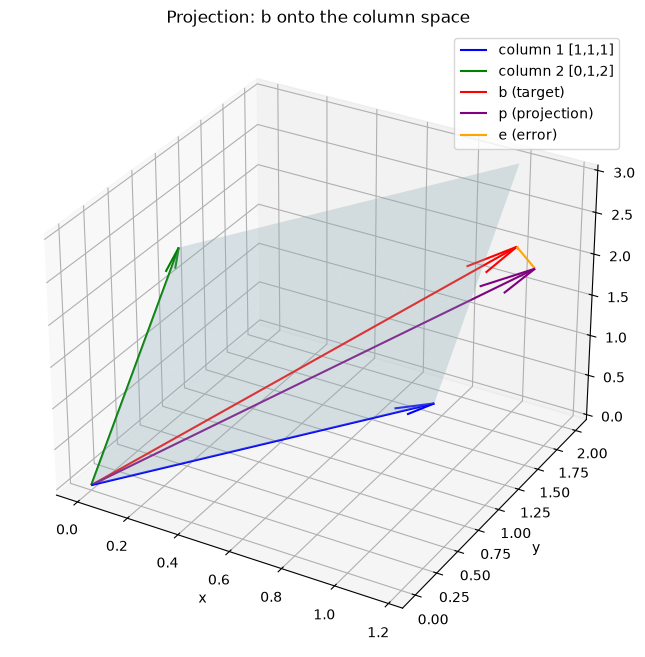


用 np.linalg.lstsq 验证:
解: [1.16666667 0.5       ]
残差平方和: 0.166667
残差平方和 = ||e||^2 = 0.166667


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 问题：找一条直线 y = m*x + c 拟合数据点 ----
# 数据点: (0,1), (1,2), (2,2)
# 方程: c + m*0 = 1, c + m*1 = 2, c + m*2 = 2

A = np.array([
    [1, 0],
    [1, 1],
    [1, 2]
])  # 第一列是截距，第二列是斜率
b = np.array([1, 2, 2])

print("=" * 60)
print("投影：最小二乘的几何本质")
print("=" * 60)
print("A = \n", A)
print("b =", b)
print("A 的列空间是 2D 平面（由 [1,1,1]^T 和 [0,1,2]^T 张成）")
print("b 不在这个平面上（3个点不在一条直线上）")

# ---- 用正规方程求解投影 ----
# 正规方程: A^T A x = A^T b
x_hat = np.linalg.solve(A.T @ A, A.T @ b)
print(f"\n最小二乘解: x = {x_hat} (截距 = {x_hat[0]:.3f}, 斜率 = {x_hat[1]:.3f})")

# ---- 计算投影 p 和误差 e ----
p = A @ x_hat  # 投影：列空间中最接近 b 的点
e = b - p      # 误差：垂直于列空间

print(f"\n投影 p = {p}")
print(f"误差 e = {e}")

# ---- 验证：e 垂直于列空间的基 ----
col1 = A[:, 0]  # [1,1,1]
col2 = A[:, 1]  # [0,1,2]
print(f"\n验证 e 垂直于列空间:")
print(f"e·col1 = {np.dot(e, col1):.6f} (应为0)")
print(f"e·col2 = {np.dot(e, col2):.6f} (应为0)")

# ---- 可视化：3D空间中的投影 ----
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 列空间的基
ax.quiver(0, 0, 0, col1[0], col1[1], col1[2], color='blue', arrow_length_ratio=0.1, label='column 1 [1,1,1]')
ax.quiver(0, 0, 0, col2[0], col2[1], col2[2], color='green', arrow_length_ratio=0.1, label='column 2 [0,1,2]')

# 列空间平面（两个基张成的平面）
# 在平面上生成点
s = np.linspace(0, 1, 10)
t = np.linspace(0, 1, 10)
S, T = np.meshgrid(s, t)
plane_points = S.flatten()[:, None] * col1 + T.flatten()[:, None] * col2
X_plane = plane_points[:, 0].reshape(10, 10)
Y_plane = plane_points[:, 1].reshape(10, 10)
Z_plane = plane_points[:, 2].reshape(10, 10)
ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.3, color='lightblue')

# b 向量
ax.quiver(0, 0, 0, b[0], b[1], b[2], color='red', arrow_length_ratio=0.1, label='b (target)')

# p 向量（投影）
ax.quiver(0, 0, 0, p[0], p[1], p[2], color='purple', arrow_length_ratio=0.1, label='p (projection)')

# e 向量（误差）
ax.quiver(p[0], p[1], p[2], e[0], e[1], e[2], color='orange', arrow_length_ratio=0.1, label='e (error)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Projection: b onto the column space')
ax.legend()
plt.show()

# ---- 用 np.linalg.lstsq 验证 ----
x_lstsq, resid, rank, s = np.linalg.lstsq(A, b, rcond=None)
print(f"\n用 np.linalg.lstsq 验证:")
print(f"解: {x_lstsq}")
print(f"残差平方和: {resid[0]:.6f}")
print(f"残差平方和 = ||e||^2 = {np.dot(e, e):.6f}")